# 단계 4.3 — Track B Feature Mart EDA (미래 공변량 시각화)

> **목적**: `feature_mart_track_b_per_site`는 `feature_mart_per_site`와 동일한 행·분할에 **`fcst_{변수}_{h:03d}`** (1~72시간 lead) 예보 채널이 추가된 마트다.
> **기준**: `01_data_eda.ipynb`와 동일한 로드·대표 site·발전/기상/split 검증에 더해 **미래 시계열 예보**를 확인한다.

**전제**: `bash project/scripts/build_track_b_mart.sh` 로 `project/artifacts/feature_mart_track_b_per_site/` 생성.

## 0. 라이브러리 및 경로 설정

In [1]:
import os
import re
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yaml

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
ARTIFACTS = os.path.join(PROJECT_ROOT, "artifacts")
SNAPSHOT = os.path.join(ARTIFACTS, "dataset_snapshot")
FEATURE_MART = os.path.join(ARTIFACTS, "feature_mart_track_b_per_site")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("FEATURE_MART :", FEATURE_MART)

import matplotlib
import matplotlib.font_manager as _fm

_KO_FONT_CANDIDATES = [
    "NanumGothic",
    "Noto Sans CJK KR",
    "Noto Sans CJK JP",
    "AppleGothic",
    "Malgun Gothic",
]
_available = {f.name for f in _fm.fontManager.ttflist}
_ko_font = next((f for f in _KO_FONT_CANDIDATES if f in _available), None)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
if _ko_font:
    matplotlib.rcParams["font.family"] = _ko_font
matplotlib.rcParams["axes.unicode_minus"] = False
print('폰트:', matplotlib.rcParams["font.family"])


PROJECT_ROOT : /disk1/krems/time_forecasting/project
FEATURE_MART : /disk1/krems/time_forecasting/project/artifacts/feature_mart_track_b_per_site
폰트: ['Noto Sans CJK JP']


## 1. 데이터 로드

In [2]:
with open(os.path.join(ARTIFACTS, "split_manifest.yaml")) as f:
    manifest = yaml.safe_load(f)

TRAIN_END = pd.Timestamp(manifest["split"]["train_end"])
VALID_END = pd.Timestamp(manifest["split"]["valid_end"])
TEST_END = pd.Timestamp(manifest["split"]["test_end"])
DATA_START = pd.Timestamp(manifest["data"]["data_start"])
print(f"Global Train : {DATA_START} ~ {TRAIN_END}")
print(f"Global Valid : {TRAIN_END} ~ {VALID_END}")
print(f"Global Test  : {VALID_END} ~ {TEST_END}")

with open(os.path.join(ARTIFACTS, "per_site_split_manifest.json")) as f:
    per_site_manifest = json.load(f)
SITE_BOUNDS = {int(k): v for k, v in per_site_manifest["sites"].items()}
print(f'Per-site split: {len(SITE_BOUNDS)} sites  비율={per_site_manifest["split_ratios"]}')


Global Train : 2022-01-01 00:00:00 ~ 2024-12-31 23:00:00
Global Valid : 2024-12-31 23:00:00 ~ 2025-09-30 23:00:00
Global Test  : 2025-09-30 23:00:00 ~ 2026-04-23 23:00:00
Per-site split: 100 sites  비율=[0.7, 0.15, 0.15]


In [3]:
df_meta = pd.read_parquet(os.path.join(SNAPSHOT, "plant_meta.parquet"))
df_meta = df_meta.drop_duplicates("cid_seq").set_index("cid_seq")
print(f"site 수: {len(df_meta)}")
df_meta[["plant_nm", "latitude", "longitude", "azimuth", "angle"]].head()


site 수: 4919


,plant_nm,latitude,longitude,azimuth,angle
cid_seq,,,,,
1,(주)프레시코,36.142175,127.138305,25,180
2,한국건설연구소 주식회사,36.576984,127.513043,25,180
3,한국건설연구소 주식회사,36.576984,127.513043,25,180
4,한국건설연구소 주식회사,36.576984,127.513043,25,180
5,한국건설연구소 주식회사,36.576984,127.513043,25,180


In [4]:
def load_split(split: str) -> pd.DataFrame:
    split_dir = os.path.join(FEATURE_MART, split)
    frames = []
    for fname in sorted(os.listdir(split_dir)):
        if not fname.endswith(".parquet"):
            continue
        cid = int(fname.replace(".parquet", ""))
        df = pd.read_parquet(os.path.join(split_dir, fname))
        df["cid_seq"] = cid
        frames.append(df)
    return pd.concat(frames).sort_index()


print("train 로드...")
df_train = load_split("train")
print("valid 로드...")
df_valid = load_split("valid")
print("test  로드...")
df_test = load_split("test")

df_all = pd.concat(
    [
        df_train.assign(split="train"),
        df_valid.assign(split="valid"),
        df_test.assign(split="test"),
    ]
).sort_index()

print(f"train {df_train.shape}  valid {df_valid.shape}  test {df_test.shape}")
print(f"all  {df_all.shape}  {df_all.index.min()} ~ {df_all.index.max()}")


train 로드...
valid 로드...
test  로드...
train (850620, 681)  valid (182293, 681)  test (182327, 681)
all  (1215240, 682)  2023-11-10 00:00:00 ~ 2026-04-23 23:00:00


In [5]:
tb_path = os.path.join(FEATURE_MART, "track_b_build_report.json")
if os.path.isfile(tb_path):
    with open(tb_path) as f:
        tb_report = json.load(f)
    print("track_b_build_report.json 요약:")
    for k in (
        "track_b_version",
        "join_mode",
        "fcst_schema",
        "horizon_max",
        "fcst_value_cols",
        "n_parquet_written",
        "total_rows",
    ):
        if k in tb_report:
            print(f"  {k}: {tb_report[k]}")
else:
    tb_report = {}
    print("track_b_build_report.json 없음")

with open(os.path.join(FEATURE_MART, "quality_report.json")) as f:
    qr = json.load(f)
print("quality_report keys:", list(qr.keys()))


track_b_build_report.json 요약:
  track_b_version: 1.2
  join_mode: era5_hourly_valid
  fcst_schema: shortterm_aligned
  horizon_max: 72
  fcst_value_cols: ['tmp', 'reh', 'wsd', 'vec', 'sky', 'pty', 'pop', 'pcp', 'sno']
  n_parquet_written: 300
  total_rows: 1215240
quality_report keys: ['checked_at', 'split_mode', 'note', 'splits', 'issues', 'warnings', 'overall_pass']


In [6]:
BASE_COLS = [c for c in df_train.columns if not str(c).startswith("fcst_")]
FCST_COLS = sorted(c for c in df_train.columns if str(c).startswith("fcst_"))
print(f"기본 컬럼 수: {len(BASE_COLS)}  fcst_* 컬럼 수: {len(FCST_COLS)}")
if FCST_COLS:
    print("fcst 예시:", FCST_COLS[:3], "...", FCST_COLS[-1:])


기본 컬럼 수: 33  fcst_* 컬럼 수: 648
fcst 예시: ['fcst_pcp_001', 'fcst_pcp_002', 'fcst_pcp_003'] ... ['fcst_wsd_072']


---
## 2. 대표 site (2025년 낮 발전 품질 기준)

In [7]:
df_2025 = df_all[df_all.index.year == 2025]
df_2025_day = df_2025[df_2025["solar_elevation"] > 5]
site_day_mean = df_2025_day.groupby("cid_seq")["normalized_power"].mean()
site_pos_hours = df_2025_day.groupby("cid_seq")["normalized_power"].apply(lambda s: (s > 0.01).sum())
quality_sites = site_day_mean[site_day_mean > 0.15].index
site_pos_filtered = site_pos_hours[site_pos_hours.index.isin(quality_sites)]
TOP5_SITES = site_pos_filtered.sort_values(ascending=False).head(5).index.tolist()
print("TOP5_SITES:", TOP5_SITES)


TOP5_SITES: [596, 7, 8, 2162, 11]


---
## 3. Site별 발전 프로파일

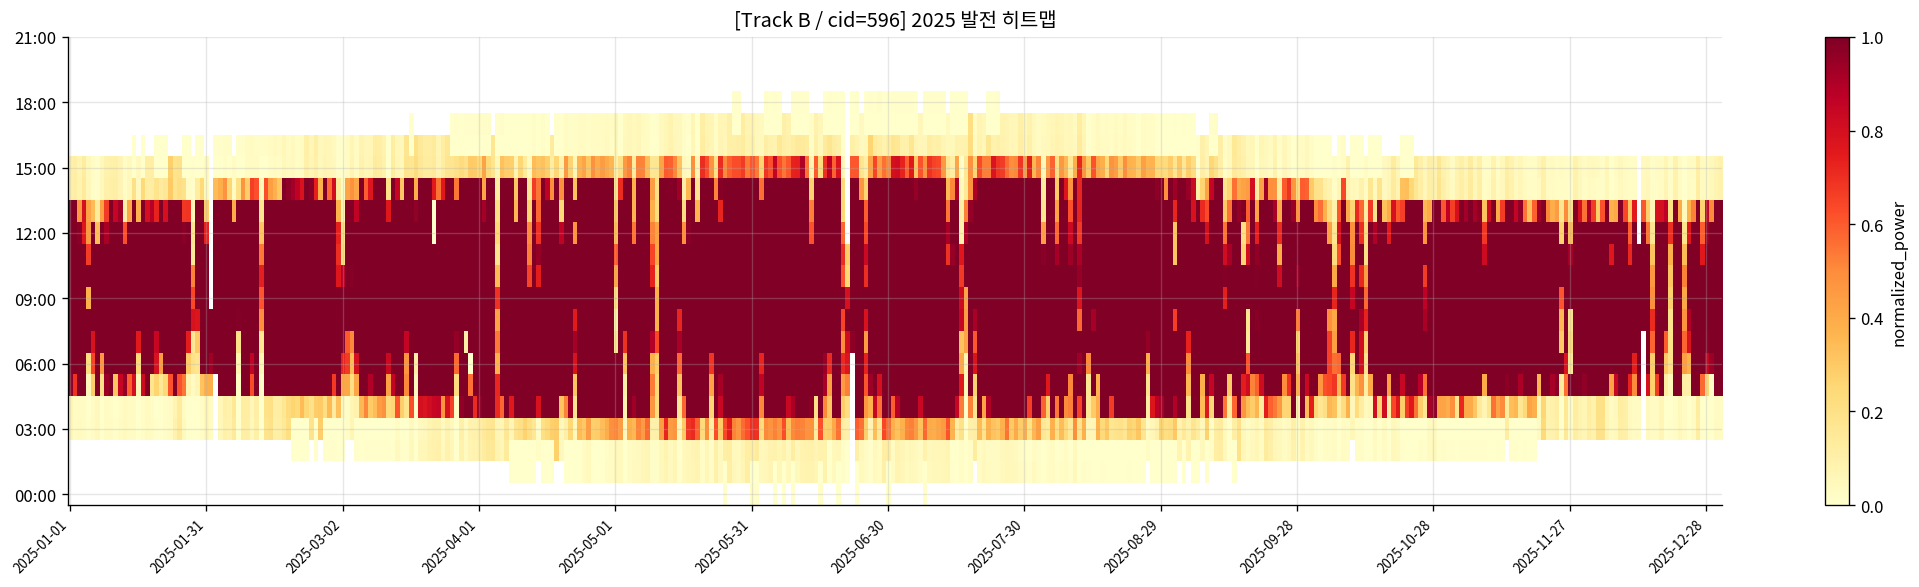

In [8]:
cid = TOP5_SITES[0]
site_df = df_all[(df_all["cid_seq"] == cid) & (df_all.index.year == 2025)].copy()
pivot = (
    site_df.assign(date=site_df.index.date, hour=site_df.index.hour)
    .pivot_table(index="hour", columns="date", values="normalized_power", aggfunc="mean")
)
fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(
    pivot.values, aspect="auto", origin="lower", cmap="YlOrRd", vmin=0, vmax=1, interpolation="nearest"
)
plt.colorbar(im, ax=ax, label="normalized_power")
ax.set_yticks(range(0, 24, 3))
ax.set_yticklabels([f"{h:02d}:00" for h in range(0, 24, 3)])
ncols = pivot.shape[1]
step = max(1, ncols // 12)
ax.set_xticks(range(0, ncols, step))
ax.set_xticklabels([str(pivot.columns[i]) for i in range(0, ncols, step)], rotation=45, ha="right", fontsize=8)
ax.set_title(f"[Track B / cid={cid}] 2025 발전 히트맵")
plt.tight_layout()
plt.show()


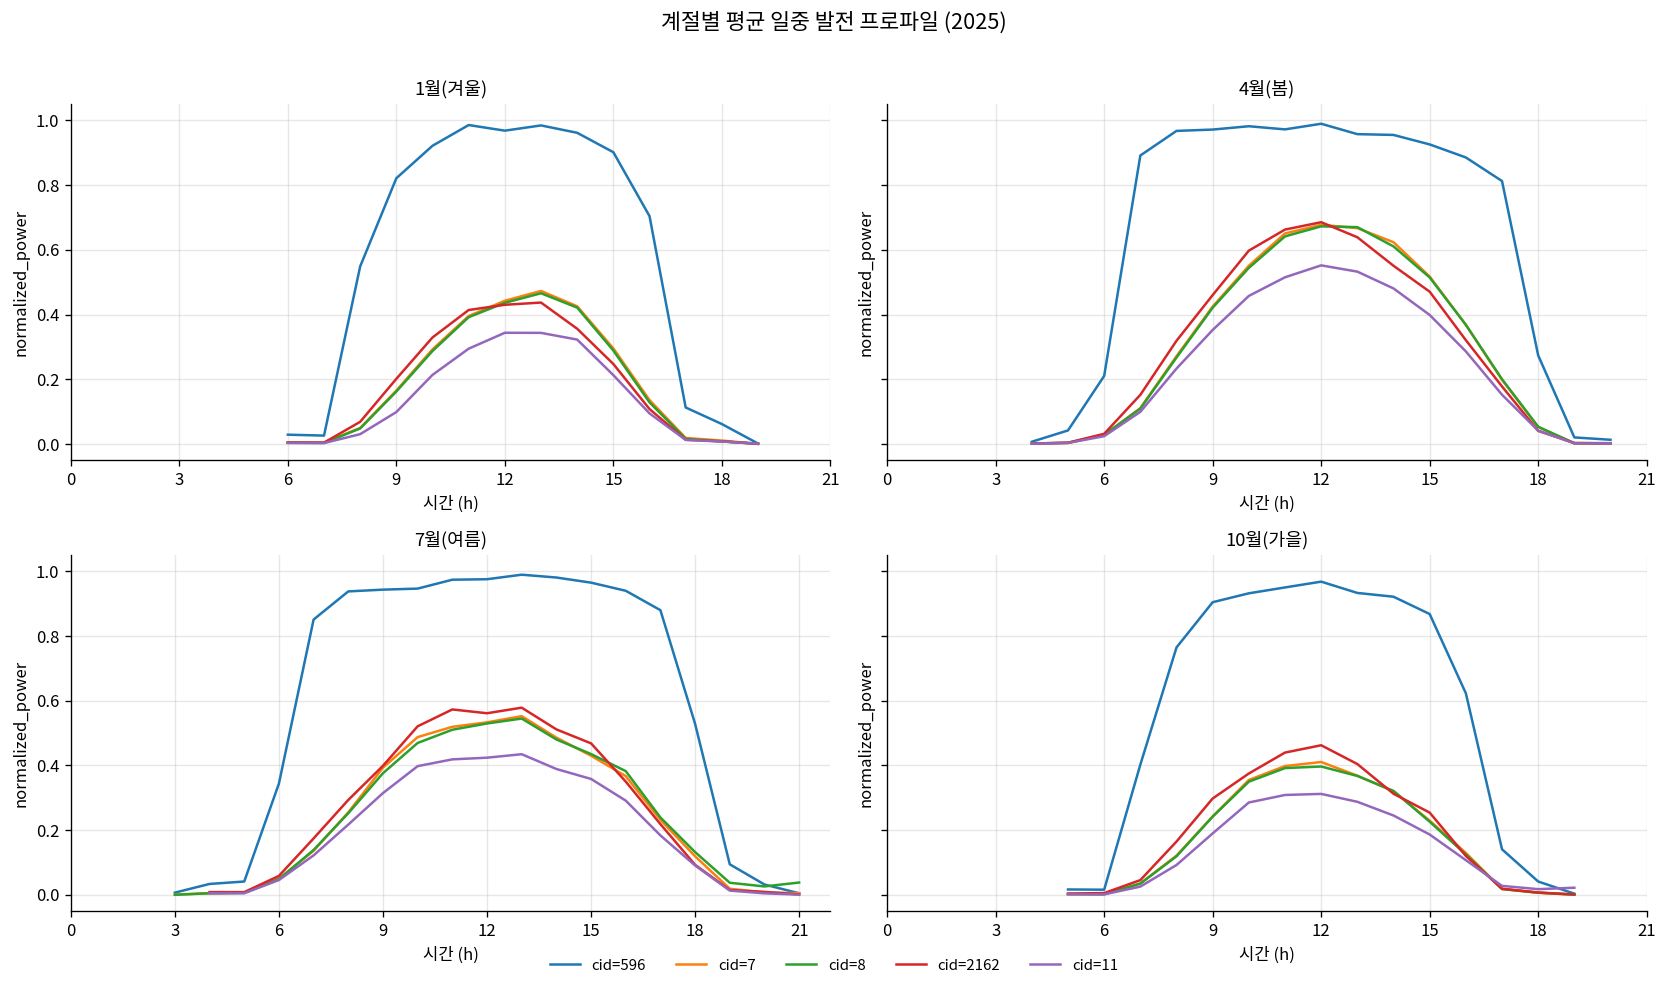

In [9]:
MONTHS_CONFIG = {1: "1월(겨울)", 4: "4월(봄)", 7: "7월(여름)", 10: "10월(가을)"}
COLORS = plt.cm.tab10.colors
PLOT_SITES = TOP5_SITES[:]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()
for ax_idx, (month, label) in enumerate(MONTHS_CONFIG.items()):
    ax = axes[ax_idx]
    for i, c in enumerate(PLOT_SITES):
        s = df_all[(df_all["cid_seq"] == c) & (df_all.index.year == 2025) & (df_all.index.month == month)]
        if len(s) == 0:
            continue
        prof = s.groupby(s.index.hour)["normalized_power"].mean()
        ax.plot(prof.index, prof.values, label=f"cid={c}", color=COLORS[i], linewidth=1.5)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("시간 (h)")
    ax.set_ylabel("normalized_power")
    ax.set_xticks(range(0, 24, 3))
    ax.set_ylim(-0.05, 1.05)
handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=5, fontsize=9, frameon=False)
fig.suptitle("계절별 평균 일중 발전 프로파일 (2025)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## 4. 계절별 clearsky vs 발전

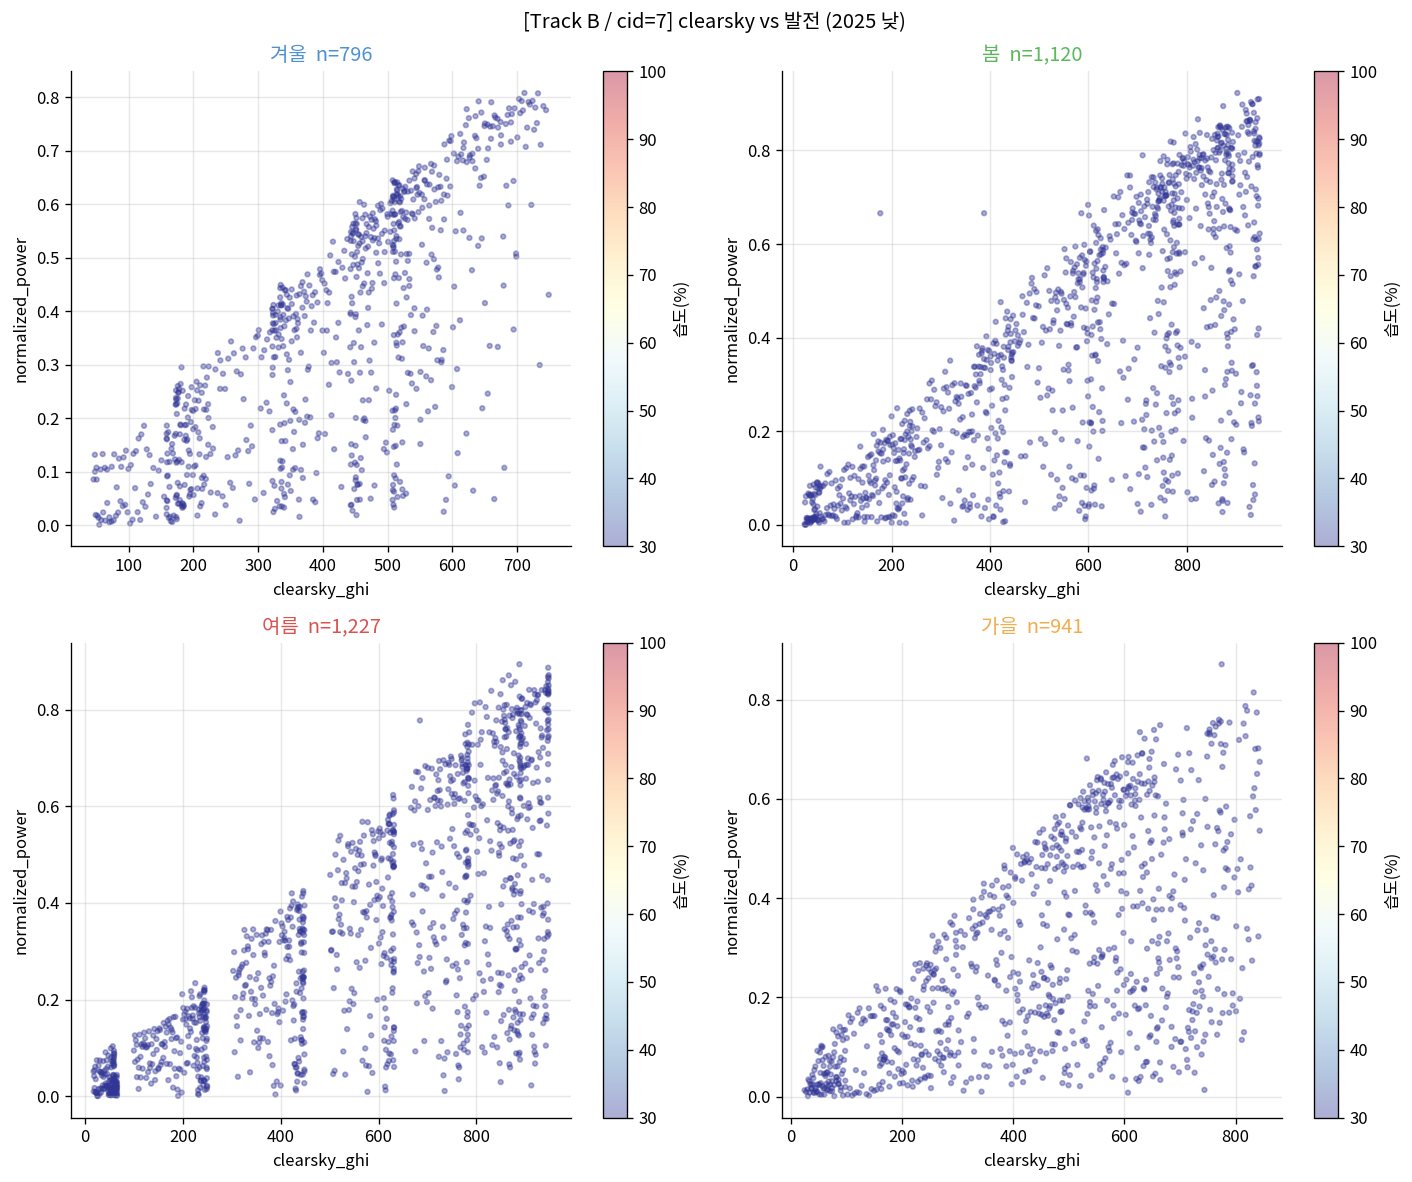

In [10]:
SEASON_MAP = {12: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2, 9: 3, 10: 3, 11: 3}
SEASON_NAMES = ["겨울", "봄", "여름", "가을"]
SEASON_COLORS = ["#4e91d2", "#5cb85c", "#d9534f", "#f0ad4e"]
cid = TOP5_SITES[1]
sdf_2025 = df_all[(df_all["cid_seq"] == cid) & (df_all.index.year == 2025) & (df_all["solar_elevation"] > 5)].copy()
sdf_2025["season"] = sdf_2025.index.month.map(SEASON_MAP)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for s_idx in range(4):
    ax = axes[s_idx]
    data = sdf_2025[sdf_2025["season"] == s_idx]
    if len(data) == 0:
        ax.set_title(f"{SEASON_NAMES[s_idx]} (데이터 없음)")
        continue
    sample = data.sample(min(3000, len(data)), random_state=42)
    sc = ax.scatter(
        sample["clearsky_ghi"],
        sample["normalized_power"],
        c=sample["hm"],
        cmap="RdYlBu_r",
        alpha=0.4,
        s=8,
        vmin=30,
        vmax=100,
    )
    plt.colorbar(sc, ax=ax, label="습도(%)")
    ax.set_xlabel("clearsky_ghi")
    ax.set_ylabel("normalized_power")
    ax.set_title(f"{SEASON_NAMES[s_idx]}  n={len(sample):,}", color=SEASON_COLORS[s_idx])
fig.suptitle(f"[Track B / cid={cid}] clearsky vs 발전 (2025 낮)", fontsize=12)
plt.tight_layout()
plt.show()


---
## 5. 기상 feature 분포

In [11]:
with open(os.path.join(FEATURE_MART, "scaler_stats.json")) as f:
    scaler_stats_raw = json.load(f)
scaler_stats = scaler_stats_raw.get("features", scaler_stats_raw)
print("정규화 feature 수:", len(scaler_stats), "  fit_end:", scaler_stats_raw.get("fit_end", "N/A"))


정규화 feature 수: 23   fit_end: 2024-12-31 23:00:00


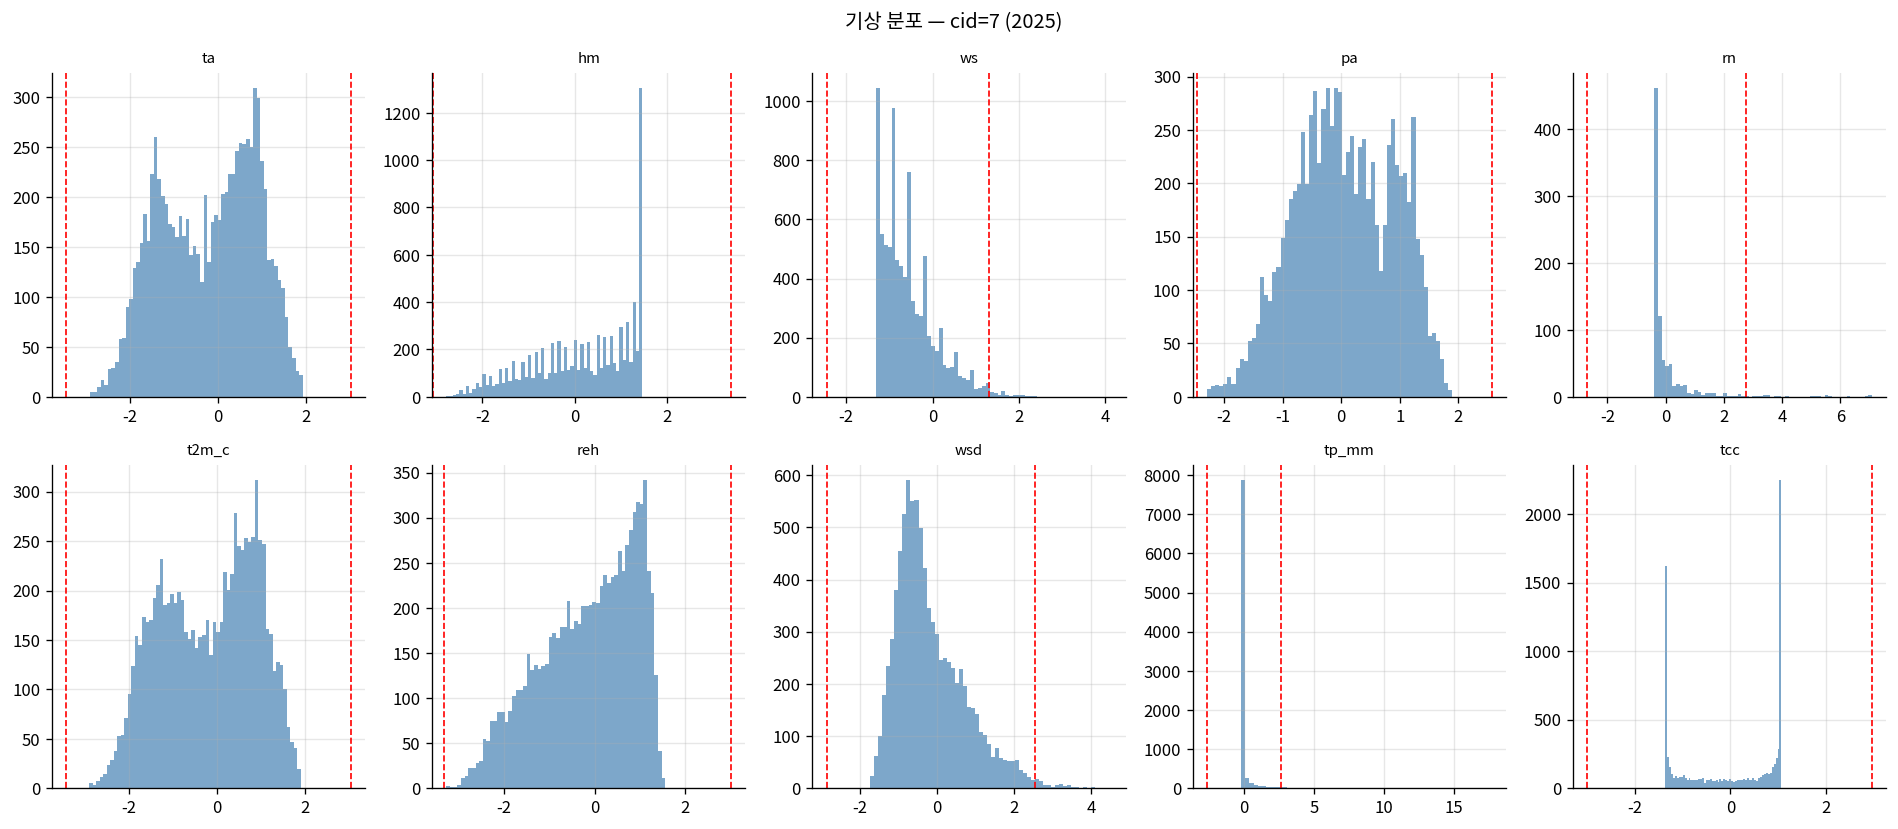

In [12]:
WEATHER_COLS = ["ta", "hm", "ws", "pa", "rn", "t2m_c", "reh", "wsd", "tp_mm", "tcc"]
WEATHER_COLS = [c for c in WEATHER_COLS if c in df_all.columns]
_cid_hist = TOP5_SITES[1]
sample_df = df_all[(df_all["cid_seq"] == _cid_hist) & (df_all.index.year == 2025)]
n_cols = 5
n_rows = int(np.ceil(len(WEATHER_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = np.atleast_1d(axes).flatten()
for i, col in enumerate(WEATHER_COLS):
    ax = axes[i]
    d = sample_df[col].dropna()
    ax.hist(d, bins=60, color="steelblue", alpha=0.7, edgecolor="none")
    m, s = d.mean(), d.std()
    ax.axvline(m + 3 * s, color="red", linestyle="--", linewidth=1)
    ax.axvline(m - 3 * s, color="red", linestyle="--", linewidth=1)
    ax.set_title(col, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle(f"기상 분포 — cid={_cid_hist} (2025)", fontsize=12)
plt.tight_layout()
plt.show()


---
## 6. Train / Valid / Test 경계

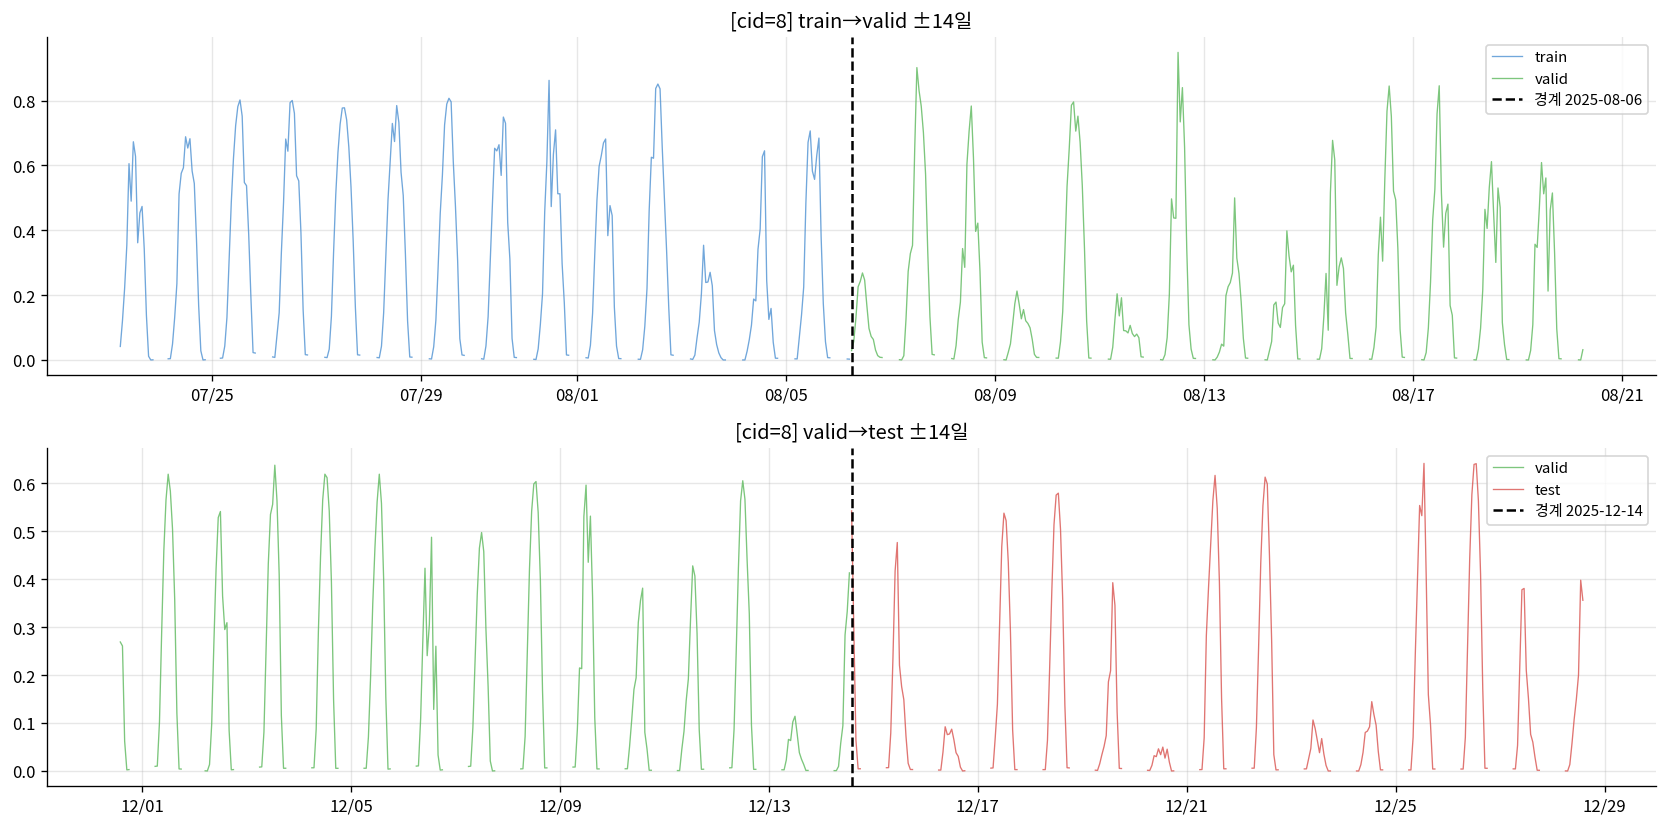

In [13]:
def _boundary_quality(cid, site_all, bounds, window_days=14):
    if not bounds:
        return 0
    train_end = pd.Timestamp(bounds["train_end"])
    w = pd.Timedelta(days=window_days)
    window = site_all[
        (site_all.index >= train_end - w)
        & (site_all.index <= train_end + w)
        & (site_all["solar_elevation"] > 5)
    ]
    return int((window["normalized_power"] > 0.01).sum())


_bq = {c: _boundary_quality(c, df_all[df_all["cid_seq"] == c], SITE_BOUNDS.get(c, {})) for c in TOP5_SITES}
cid_b = max(_bq, key=_bq.get)
bounds = SITE_BOUNDS.get(cid_b, {})
site_train_end = pd.Timestamp(bounds.get("train_end", str(TRAIN_END)))
site_valid_end = pd.Timestamp(bounds.get("valid_end", str(VALID_END)))
site_all = df_all[df_all["cid_seq"] == cid_b].copy()


def get_boundary_window(site_df, boundary_ts, window_days=14):
    w = pd.Timedelta(days=window_days)
    left = site_df[(site_df.index >= boundary_ts - w) & (site_df.index < boundary_ts)]
    right = site_df[(site_df.index >= boundary_ts) & (site_df.index <= boundary_ts + w)]
    return left, right


SPLIT_COLORS = {"train": "#4e91d2", "valid": "#5cb85c", "test": "#d9534f"}
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax_idx, (split_ts, L, R) in enumerate([(site_train_end, "train", "valid"), (site_valid_end, "valid", "test")]):
    ax = axes[ax_idx]
    left, right = get_boundary_window(site_all, split_ts)
    ax.plot(left.index, left["normalized_power"], color=SPLIT_COLORS[L], alpha=0.8, linewidth=0.8, label=L)
    ax.plot(right.index, right["normalized_power"], color=SPLIT_COLORS[R], alpha=0.8, linewidth=0.8, label=R)
    ax.axvline(split_ts, color="black", linestyle="--", linewidth=1.5, label=f"경계 {split_ts.date()}")
    ax.set_title(f"[cid={cid_b}] {L}→{R} ±14일")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
plt.tight_layout()
plt.show()


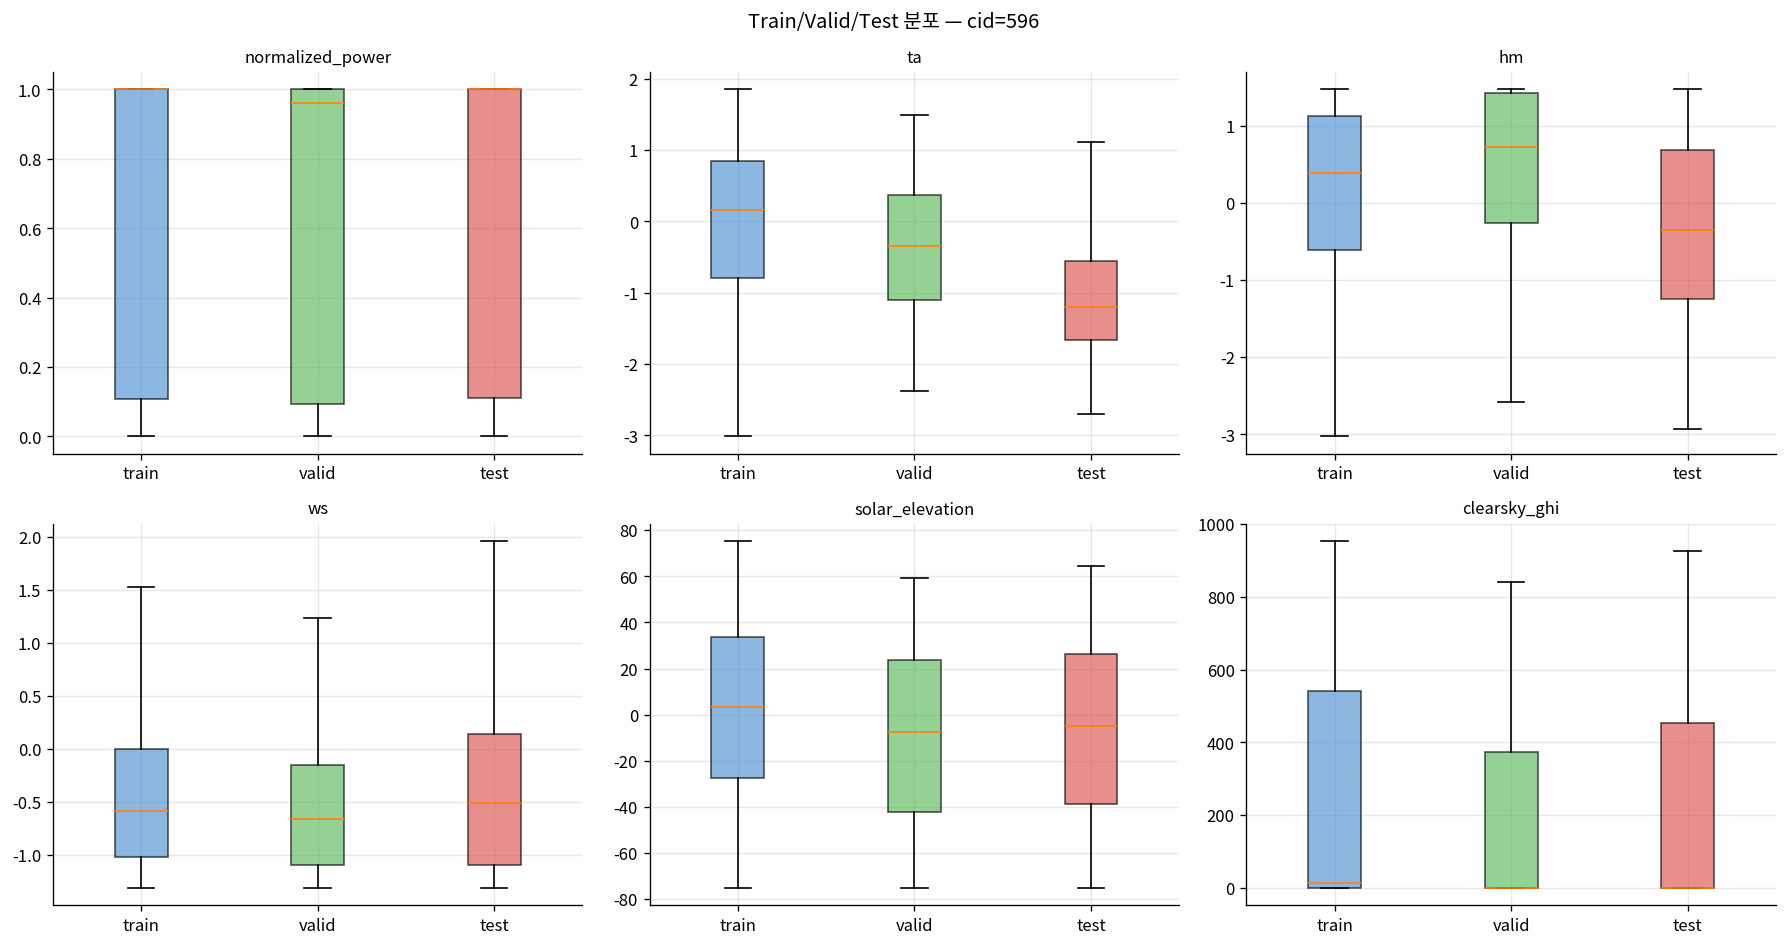

In [14]:
COMPARE_COLS = ["normalized_power", "ta", "hm", "ws", "solar_elevation", "clearsky_ghi"]
COMPARE_COLS = [c for c in COMPARE_COLS if c in df_train.columns]
N_SAMPLE = 20000
cid0 = TOP5_SITES[0]
samples = {}
for name, sdf in [("train", df_train), ("valid", df_valid), ("test", df_test)]:
    site_df = sdf[sdf["cid_seq"] == cid0]
    samples[name] = site_df[COMPARE_COLS].sample(min(N_SAMPLE, len(site_df)), random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(COMPARE_COLS):
    ax = axes[i]
    data_list = [samples[s][col].dropna().values for s in ["train", "valid", "test"]]
    pack = [
        (d, n, c)
        for d, n, c in zip(data_list, ["train", "valid", "test"], SPLIT_COLORS.values())
        if len(d) > 1
    ]
    if not pack:
        ax.set_title(f"{col} (없음)")
        continue
    bp = ax.boxplot(
        [d for d, _, _ in pack],
        labels=[n for _, n, _ in pack],
        patch_artist=True,
        showfliers=False,
    )
    for patch, (_, _, color) in zip(bp["boxes"], pack):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax.set_title(col, fontsize=10)
fig.suptitle(f"Train/Valid/Test 분포 — cid={cid0}", fontsize=12)
plt.tight_layout()
plt.show()


---
## 7. 미래 예보 채널 (`fcst_*`) — Track B 전용

행 시각 $t$에서 **`fcst_tmp_h`** 등은 빌드 설정(`track_b_build_report.json`의 `join_mode`, `fcst_schema`)에 맞게 **lead $h$ 시간 뒤 기상**에 정렬된 예보값이다.

- **히트맵**: 시간 × lead (예: `fcst_tmp_001` … `fcst_tmp_072`)
- **산점도**: `fcst_tmp_h`(t) vs 실측 `t2m_c`(t+h) 로 lead별 일치도 확인

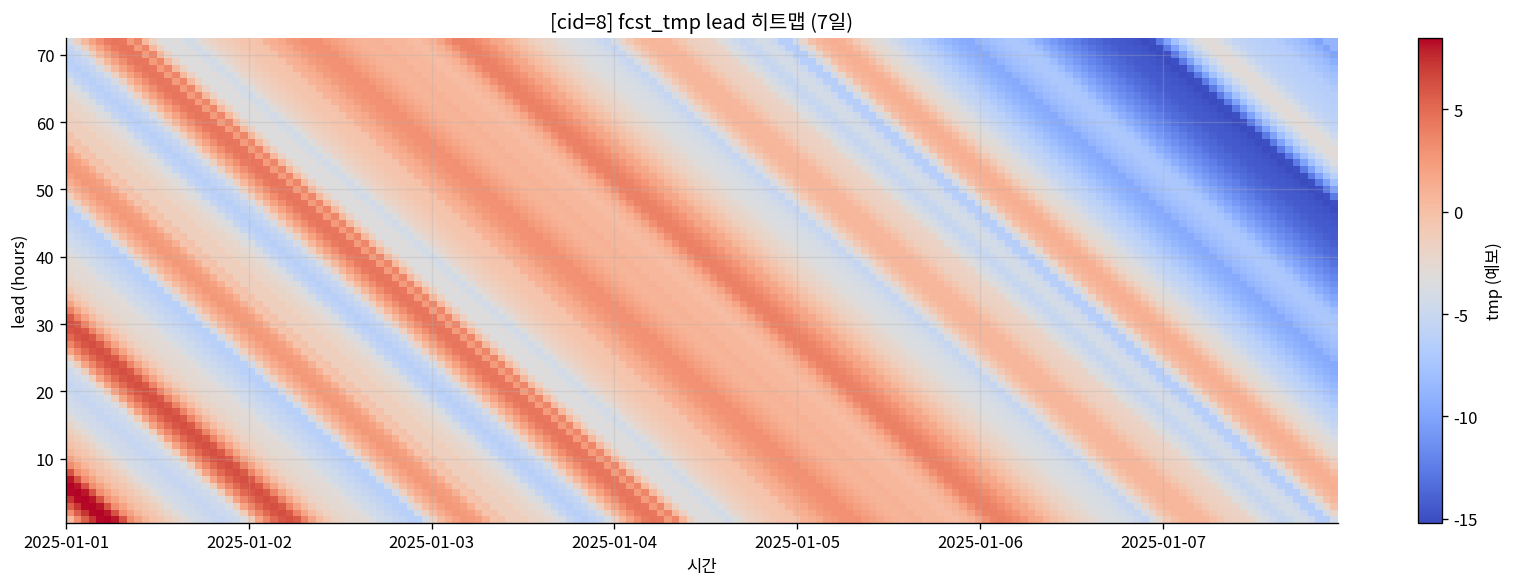

mat (168, 72) H 72


In [15]:
def fcst_lead_cols(df, prefix="fcst_tmp_"):
    cols = [c for c in df.columns if c.startswith(prefix)]
    return sorted(cols, key=lambda c: int(c.split("_")[-1]))


cid_fc = TOP5_SITES[2]
sfc = df_all[df_all["cid_seq"] == cid_fc].sort_index()
start = sfc[sfc.index.year == 2025].index.min()
if pd.isna(start):
    start = sfc.index.min()
chunk = sfc.loc[start : start + pd.Timedelta(hours=167)]
tmp_cols = fcst_lead_cols(chunk, "fcst_tmp_")
if not tmp_cols:
    raise RuntimeError("fcst_tmp_* 없음 — Track B 마트인지 확인")
H = len(tmp_cols)
mat = chunk[tmp_cols].to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    mat.T,
    aspect="auto",
    origin="lower",
    cmap="coolwarm",
    extent=[
        mdates.date2num(chunk.index[0]),
        mdates.date2num(chunk.index[-1]),
        0.5,
        H + 0.5,
    ],
)
ax.set_ylabel("lead (hours)")
ax.set_xlabel("시간")
ax.xaxis_date()
ax.set_title(f"[cid={cid_fc}] fcst_tmp lead 히트맵 (7일)")
plt.colorbar(im, ax=ax, label="tmp (예보)")
plt.tight_layout()
plt.show()
print("mat", mat.shape, "H", H)


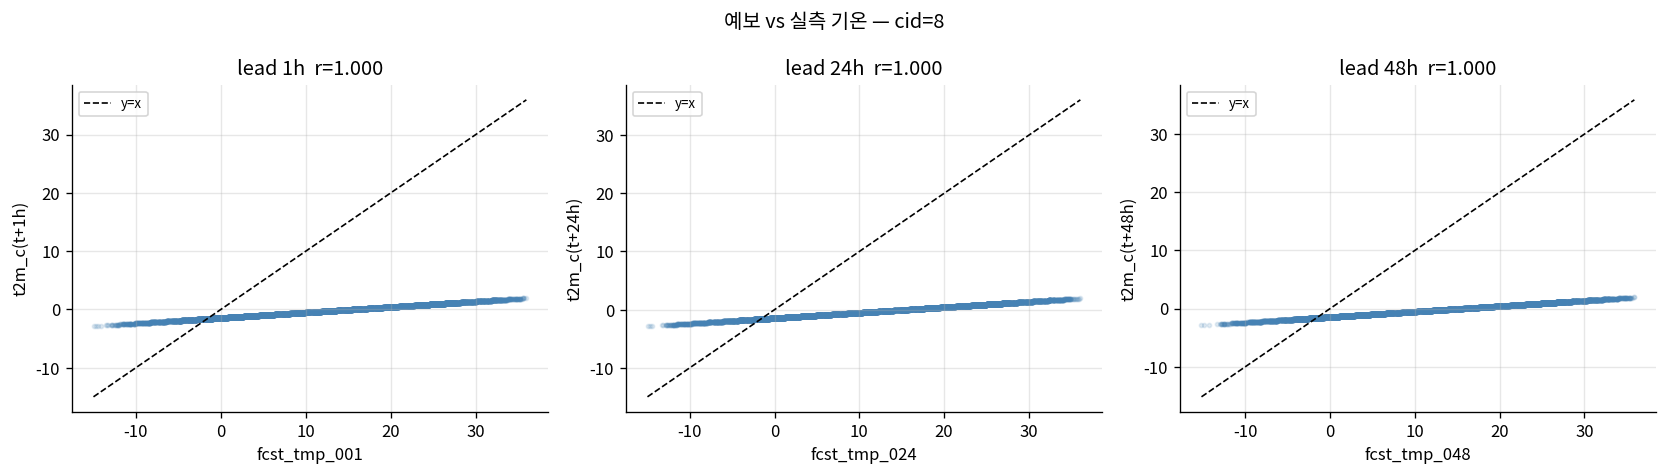

In [16]:
if "t2m_c" not in sfc.columns:
    print("t2m_c 없음 — 스킵")
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, h in zip(axes, [1, 24, 48]):
        col = f"fcst_tmp_{h:03d}"
        if col not in sfc.columns:
            ax.set_visible(False)
            continue
        y = sfc["t2m_c"].shift(-h)
        x = sfc[col]
        m = pd.concat([x, y], axis=1).dropna()
        if len(m) > 8000:
            m = m.sample(8000, random_state=h)
        ax.scatter(m.iloc[:, 0], m.iloc[:, 1], alpha=0.15, s=6, c="steelblue")
        lo = min(m.min().min(), -15)
        hi = max(m.max().max(), 35)
        ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="y=x")
        ax.set_xlabel(col)
        ax.set_ylabel(f"t2m_c(t+{h}h)")
        r = m.iloc[:, 0].corr(m.iloc[:, 1])
        rtxt = f"{r:.3f}" if pd.notna(r) else "nan"
        ax.set_title(f"lead {h}h  r={rtxt}")
        ax.legend(fontsize=8)
    fig.suptitle(f"예보 vs 실측 기온 — cid={cid_fc}", fontsize=12)
    plt.tight_layout()
    plt.show()


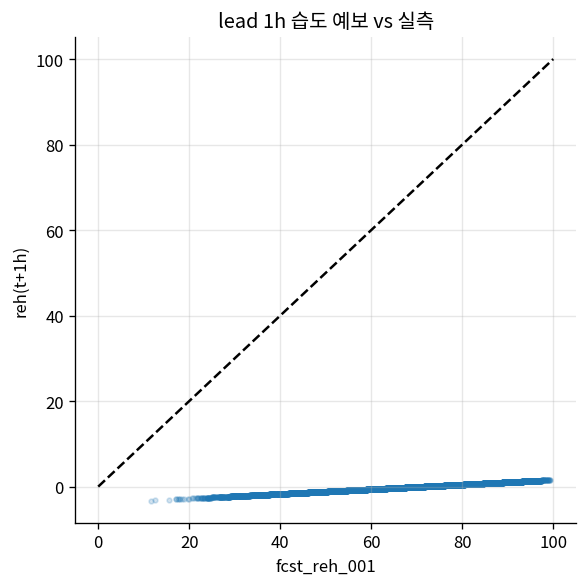

In [17]:
if "reh" in sfc.columns and "fcst_reh_001" in sfc.columns:
    m = pd.concat([sfc["fcst_reh_001"], sfc["reh"].shift(-1)], axis=1).dropna()
    if len(m) > 6000:
        m = m.sample(6000, random_state=1)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(m.iloc[:, 0], m.iloc[:, 1], alpha=0.2, s=8)
    ax.plot([0, 100], [0, 100], "k--")
    ax.set_xlabel("fcst_reh_001")
    ax.set_ylabel("reh(t+1h)")
    ax.set_title("lead 1h 습도 예보 vs 실측")
    plt.tight_layout()
    plt.show()
else:
    print("reh 또는 fcst_reh_001 없음 — 스킵")


---
## 8. 요약

In [18]:
from IPython.display import Markdown

n_fcst = len([c for c in df_train.columns if str(c).startswith("fcst_")])
md_lines = [
    "| 항목 | 값 |",
    "|------|-----|",
    f"| Track B mart | `{FEATURE_MART}` |",
    f"| all 행 / site 수 | {len(df_all):,} / {df_all['cid_seq'].nunique()} |",
    f"| fcst_* 컬럼 수 | {n_fcst} |",
    f"| 대표 TOP5 | {TOP5_SITES} |",
]
display(Markdown("\n".join(md_lines)))
print("EDA 셀 실행 완료.")


| 항목 | 값 |
|------|-----|
| Track B mart | `/disk1/krems/time_forecasting/project/artifacts/feature_mart_track_b_per_site` |
| all 행 / site 수 | 1,215,240 / 100 |
| fcst_* 컬럼 수 | 648 |
| 대표 TOP5 | [596, 7, 8, 2162, 11] |

EDA 셀 실행 완료.


---
## 9. Track B 실제 데이터 구조 — **1행 = 1시각 × 1site (wide)**

`track_b_build_report.json`의 `added_columns`가 길게 보이는 이유는, **시간축으로 행을 늘리는 것이 아니라** 같은 행(시각 $t$)에 **lead 1…H시간**마다 값을 **서로 다른 컬럼**으로 붙였기 때문이다.

| 구분 | 의미 |
|------|------|
| **행** | `DatetimeIndex` 한 시각 + `cid_seq`로 site 구분 (parquet 파일당 한 site) |
| **기존 컬럼** | 발전·ERA5·파생 feature 등 (기본 mart와 동일) |
| **`fcst_{변수}_{h:03d}`** | 그 시각 $t$에서 본 **$t+h$ 시각 기상**에 대한 예보값 (wide, $h=1\ldots H$) |

즉 **한 행의 너비**가 `기본 feature 수 + (변수 수 × H)`로 커진다. 아래 셀에서 **실제 1행**을 뽑아 표와 배열 shape으로 확인한다.

> 참고: 현재 `project/src/datasets/pv_dataset.py`의 `FEATURE_COLS`는 **32개 기본 채널만** 사용한다. Track B의 `fcst_*`를 학습 배치에 넣으려면 별도로 feature 목록·Dataset을 확장해야 한다.

In [19]:
# --- 실제 1행(1 시각) 데이터: wide 구조 확인 ---
from IPython.display import display

_demo_cid = TOP5_SITES[0]
_one_site = df_all[df_all["cid_seq"] == _demo_cid].sort_index()
# fcst가 채워진 행 우선
_ok = _one_site.dropna(subset=["fcst_tmp_001"], how="any")
if len(_ok) == 0:
    _ok = _one_site
row = _ok.iloc[[len(_ok) // 2]]  # 중간 시각 1행
t0 = row.index[0]

base_show = [
    c
    for c in row.columns
    if not str(c).startswith("fcst_") and c not in ("cid_seq", "split")
][:16]
print("=== 시각 / site ===")
print("  index (UTC/KST 그대로):", t0, "  cid_seq:", int(row["cid_seq"].iloc[0]))
print("\n=== 기존 feature 일부 (wide의 한 컬럼 = 한 값) ===")
display(row[base_show].T)

tmp_cols = sorted(
    [c for c in row.columns if c.startswith("fcst_tmp_")],
    key=lambda c: int(c.split("_")[-1]),
)
reh_cols = sorted(
    [c for c in row.columns if c.startswith("fcst_reh_")],
    key=lambda c: int(c.split("_")[-1]),
)

if tmp_cols:
    fan_tmp = row[tmp_cols].T
    fan_tmp.columns = ["value"]
    fan_tmp.index.name = "column"
    fan_tmp = fan_tmp.reset_index()
    fan_tmp["lead_h"] = fan_tmp["column"].str.replace("fcst_tmp_", "").astype(int)
    print(f"\n=== fcst_tmp_* 한 행에서의 lead 전개 (총 {len(tmp_cols)} lead) ===")
    display(fan_tmp[["lead_h", "value"]].head(12))
    print("...")
    display(fan_tmp[["lead_h", "value"]].tail(8))

if reh_cols:
    print(f"\nfcst_reh_* 컬럼 수: {len(reh_cols)} (예: 첫 5 lead)")
    display(row[reh_cols[:5]].T)

# split 등 비수치 컬럼 제외 후 1행 벡터 (학습 시 feature 행으로 쓰는 형태)
_row_num = row.drop(columns=["split"], errors="ignore").select_dtypes(include=[np.number, "bool"])
arr = _row_num.to_numpy(dtype=np.float64)
print("\n=== 이 1행을 수치 행벡터로 본 경우 ===")
print("  사용 컬럼 수:", _row_num.shape[1], "(split 등 문자열 제외)")
print("  arr.shape:", arr.shape, "  (= (1, F_numeric))")
print("  전체 컬럼 수(원본):", row.shape[1], "  fcst_* 개수:", len([c for c in row.columns if str(c).startswith("fcst_")]))

batch_like = arr[np.newaxis, :] if arr.ndim == 1 else arr
print("\n=== numpy batch_like (batch=1, F_numeric) ===")
print("  batch_like.shape:", batch_like.shape)

=== 시각 / site ===
  index (UTC/KST 그대로): 2025-03-31 02:00:00   cid_seq: 596

=== 기존 feature 일부 (wide의 한 컬럼 = 한 값) ===


timestamp,2025-03-31 02:00:00
normalized_power,NaN
ta,-1.416139
rn,NaN
ws,-1.022312
wd,-1.557289
hm,0.086865
pa,1.142993
si,NaN
ss,NaN
dc10Tca,1.014075



=== fcst_tmp_* 한 행에서의 lead 전개 (총 72 lead) ===


,lead_h,value
0,1,11.868805
1,2,12.785553
2,3,13.840240
3,4,13.934967
4,5,13.616852
5,6,12.932770
6,7,11.876740
7,8,9.050079
8,9,7.887604
9,10,5.830963


...


,lead_h,value
64,65,2.762360
65,66,2.268219
66,67,2.126862
67,68,3.227936
68,69,4.609772
69,70,6.849274
70,71,9.015533
71,72,11.449860



fcst_reh_* 컬럼 수: 72 (예: 첫 5 lead)


timestamp,2025-03-31 02:00:00
fcst_reh_001,39.331448
fcst_reh_002,33.302986
fcst_reh_003,29.566893
fcst_reh_004,28.658604
fcst_reh_005,29.656553



=== 이 1행을 수치 행벡터로 본 경우 ===
  사용 컬럼 수: 681 (split 등 문자열 제외)
  arr.shape: (1, 681)   (= (1, F_numeric))
  전체 컬럼 수(원본): 682   fcst_* 개수: 648

=== numpy batch_like (batch=1, F_numeric) ===
  batch_like.shape: (1, 681)
